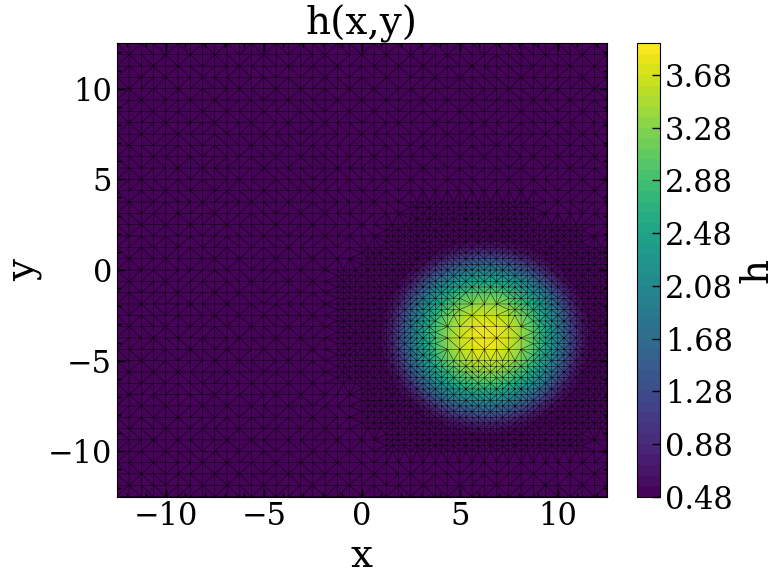

0.5145341056622981


In [212]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.tri as tri

data = np.loadtxt("domain/domain_000025.txt", skiprows=1)

x = data[:,0]
y = data[:,1]
h = data[:,2]
p = data[:,3]

triang = tri.Triangulation(x, y)

plt.tricontourf(triang, h, 50)
plt.triplot(triang, color='k', linewidth=0.3)

plt.colorbar(label="h")
plt.xlabel("x")
plt.ylabel("y")
plt.title("h(x,y)")
#plt.xlim(-2,2)
#plt.ylim(-2,2)
plt.show()
print(h[0])

In [209]:
# Measure velocity


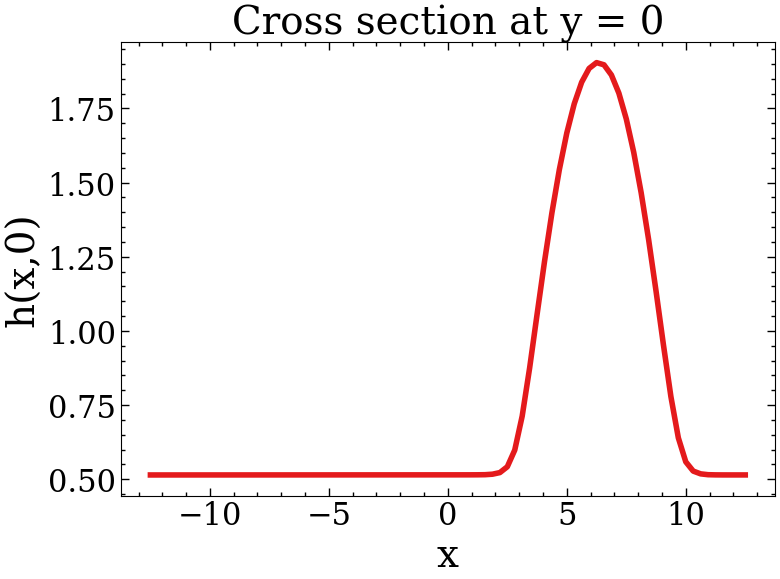

In [210]:
import numpy as np
import matplotlib.pyplot as plt

tol = 1e-6   # tolerance

mask = np.abs(y) < tol

x_slice = x[mask]
h_slice = h[mask]

plt.plot(x_slice, h_slice)
plt.xlabel("x")
plt.ylabel("h(x,0)")
plt.title("Cross section at y = 0")
plt.show()

In [211]:
from scipy.io import loadmat, savemat

data = loadmat('domain/x_.mat')

x_ = data['x']

FileNotFoundError: [Errno 2] No such file or directory: 'domain/x_.mat'

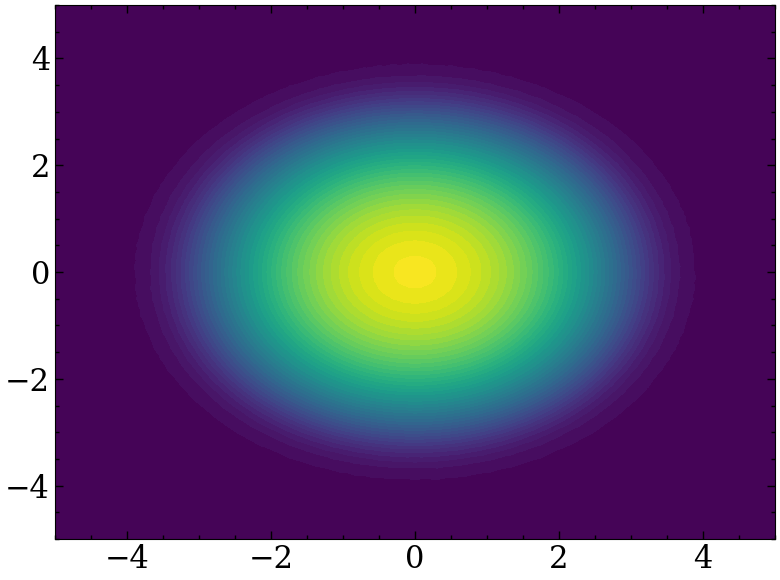

In [ ]:
import numpy as np
from scipy.interpolate import griddata

# original points
points = np.column_stack((x, y))

# new grid points
points_new = x_   # shape (N,2)

# interpolate
h_new = griddata(points, h, points_new, method='linear')
x_new = x_[:,0]
y_new = x_[:,1]

plt.tricontourf(x_new, y_new, h_new, 50)

savemat("h_ini.mat", {"h_ini": h_new})

In [ ]:
len(h_new)

4901

In [ ]:
h_new

array([0.52158981, 0.52158981, 0.52158981, ..., 0.52158981, 0.52158981,
       0.52158981], shape=(4901,))